# Xác minh Mệnh đề 2: Giảm phương sai nhờ tương quan $\rho$

Đo lại sự phân rã $TE = MI_{full} - MI_{reduced}$ và hệ số tương quan $\rho$ giữa hai số hạng này, để chứng minh kiến trúc mạng dùng chung (shared network) giúp triệt tiêu phương sai.

Var(MI_full): 0.014611
Var(MI_reduced): 0.009105
Var(TE) đo thực tế: 0.002165
Hệ số tương quan rho: 0.9343
Var(TE) dự đoán theo lý thuyết: 0.002165
Tổng phương sai độc lập (nếu rho = 0): 0.023716
Phần trăm phương sai được triệt tiêu nhờ chia sẻ mạng: 90.87%


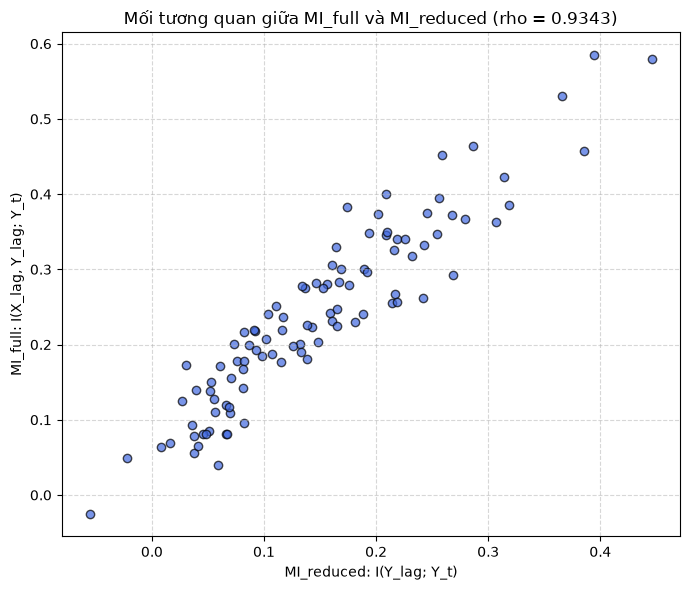

In [1]:
import sys
from pathlib import Path

# Đảm bảo import được code trong src
ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR / 'src') not in sys.path:
    sys.path.append(str(ROOT_DIR / 'src'))

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from pqrst.data.synthetic.corpus import generate_corpus
from pqrst.estimators.mine.amortized import AmortizedTEEstimator
from pqrst.estimators.mine.conditional import estimate_te_from_window

# 1. Load checkpoint Amortized đã huấn luyện sẵn
ckpt_path = ROOT_DIR / 'results' / 'checkpoints' / 'phi_amortized_standardized.pt'
assert ckpt_path.exists(), f"Không tìm thấy checkpoint tại: {ckpt_path}"
estimator = AmortizedTEEstimator.load(str(ckpt_path))

# 2. Sinh tập dữ liệu cửa sổ để kiểm tra (N=20, coupling=0.6, noise=0.5)
windows = generate_corpus(
    coupling_values=[0.6],
    noise_values=[0.5],
    n_values=[20],
    n_windows_per_cell=100,
    a=0.5,
    b=0.5,
    base_seed=42
)

# 3. Đo lường phân rã từng thành phần mi_full, mi_reduced và te
mi_full_list, mi_reduced_list, te_list = [], [], []
for i, w in enumerate(windows):
    res = estimate_te_from_window(
        model=estimator.model,
        y_t=w.y_t,
        x_lag=w.x_lag,
        y_lag=w.y_lag,
        n_shuffles=20,
        seed=42 + i
    )
    mi_full_list.append(res['mi_full'])
    mi_reduced_list.append(res['mi_reduced'])
    te_list.append(res['te'])

df = pd.DataFrame({'mi_full': mi_full_list, 'mi_reduced': mi_reduced_list, 'te': te_list})

# 4. Tính toán phương sai và hệ số tương quan rho
var_full = df['mi_full'].var()
var_reduced = df['mi_reduced'].var()
var_te = df['te'].var()
rho = df['mi_full'].corr(df['mi_reduced'])
predicted_var_te = var_full + var_reduced - 2 * rho * np.sqrt(var_full * var_reduced)

print(f"Var(MI_full): {var_full:.6f}")
print(f"Var(MI_reduced): {var_reduced:.6f}")
print(f"Var(TE) đo thực tế: {var_te:.6f}")
print(f"Hệ số tương quan rho: {rho:.4f}")
print(f"Var(TE) dự đoán theo lý thuyết: {predicted_var_te:.6f}")
print(f"Tổng phương sai độc lập (nếu rho = 0): {var_full + var_reduced:.6f}")
print(f"Phần trăm phương sai được triệt tiêu nhờ chia sẻ mạng: {(1 - var_te / (var_full + var_reduced))*100:.2f}%")

# 5. Vẽ đồ thị kiểm chứng tương quan dương giữa 2 nhánh
plt.figure(figsize=(7, 6))
plt.scatter(df['mi_reduced'], df['mi_full'], color='royalblue', alpha=0.7, edgecolors='k')
plt.title(f"Mối tương quan giữa MI_full và MI_reduced (rho = {rho:.4f})")
plt.xlabel("MI_reduced: I(Y_lag; Y_t)")
plt.ylabel("MI_full: I(X_lag, Y_lag; Y_t)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
